In [1]:
#Changing the working directory to the root
%cd ../..

c:\Users\olarinoyem\Project\hospitalization_research


In [2]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import plotly.express as px
import plotly.graph_objects as go
import plotly.subplots as sp
import plotly.io as pio

pio.templates.default = "plotly_white"
from itertools import cycle

from sklearn.metrics import mean_absolute_error as mae, mean_squared_error as mse
from tqdm.notebook import tqdm

tqdm.pandas()
# import tensorflow as tf
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import pytorch_lightning as pl
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import EarlyStopping

torch.set_float32_matmul_precision("high")
import shutil
from src.utils import plotting_utils
from src.dl.dataloaders import TimeSeriesDataModule
from src.dl.multivariate_models import SingleStepRNNConfig, SingleStepRNNModel

# For reproduceability set a random seed
pl.seed_everything(42)

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

Seed set to 42


In [3]:
source_data = Path("data/")


# Check if a GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
# try:
#     train_df = pd.read_csv(source_data / "raw/train.csv")
#     test_df = pd.read_csv(source_data / "raw/test.csv")
#     val_df = pd.read_csv(source_data / "raw/val.csv")

# except FileNotFoundError:
#     print("File not found")

try:
    train_df = pd.read_csv(source_data / "raw/targetTransf_train.csv")
    test_df = pd.read_csv(source_data / "raw/targetTransf_test.csv")
    val_df = pd.read_csv(source_data / "raw/targetTransf_val.csv")

except FileNotFoundError:
    print("File not found")

In [5]:
def format_plot(
    fig, legends=None, xlabel="Time", ylabel="Value", title="", font_size=15
):
    if legends:
        names = cycle(legends)
        fig.for_each_trace(lambda t: t.update(name=next(names)))
    fig.update_layout(
        autosize=False,
        width=900,
        height=500,
        title_text=title,
        title={"x": 0.5, "xanchor": "center", "yanchor": "top"},
        titlefont={"size": 20},
        legend_title=None,
        legend=dict(
            font=dict(size=font_size),
            orientation="h",
            yanchor="bottom",
            y=0.98,
            xanchor="right",
            x=1,
        ),
        yaxis=dict(
            title_text=ylabel,
            titlefont=dict(size=font_size),
            tickfont=dict(size=font_size),
        ),
        xaxis=dict(
            title_text=xlabel,
            titlefont=dict(size=font_size),
            tickfont=dict(size=font_size),
        ),
    )
    return fig


def mase(actual, predicted, insample_actual):
    mae_insample = np.mean(np.abs(np.diff(insample_actual)))
    mae_outsample = np.mean(np.abs(actual - predicted))
    return mae_outsample / mae_insample


def forecast_bias(actual, predicted):
    return np.mean(predicted - actual)


def plot_forecast(
    pred_df, forecast_columns, forecast_display_names=None, save_path=None
):
    if forecast_display_names is None:
        forecast_display_names = forecast_columns
    else:
        assert len(forecast_columns) == len(forecast_display_names)

    mask = ~pred_df[forecast_columns[0]].isnull()
    colors = px.colors.qualitative.Set2  # Using a different color palette
    act_color = colors[0]
    colors = cycle(colors[1:])

    fig = go.Figure()

    # Actual data plot
    fig.add_trace(
        go.Scatter(
            x=pred_df[mask].index,
            y=pred_df[mask].covidOccupiedMVBeds,
            mode="lines",
            marker=dict(size=6, opacity=0.5),
            line=dict(color=act_color, width=2),
            name="Actual COVID-19 MVBeds trends",
        )
    )

    # Predicted data plot
    for col, display_col in zip(forecast_columns, forecast_display_names):
        fig.add_trace(
            go.Scatter(
                x=pred_df[mask].index,
                y=pred_df.loc[mask, col],
                mode="lines+markers",
                marker=dict(size=4),
                line=dict(color=next(colors), width=2),
                name=display_col,
            )
        )

    return fig


def highlight_abs_min(s, props=""):
    return np.where(s == np.nanmin(np.abs(s.values)), props, "")

In [6]:
# Drop date column and convert data to float32 type
# train = train_df.drop(columns=["Unnamed: 0"])
# val = val_df.drop(columns=["Unnamed: 0"])
# test = test_df.drop(columns=["Unnamed: 0"])

train = train_df.copy()
val = val_df.copy()
test = test_df.copy()

In [7]:
# Convert date to datetime and set as index
train["date"] = pd.to_datetime(train["date"])
test["date"] = pd.to_datetime(test["date"])
val["date"] = pd.to_datetime(val["date"])

train.set_index("date", inplace=True)
test.set_index("date", inplace=True)
val.set_index("date", inplace=True)

In [8]:
# Concatenate the DataFrames
sample_df = pd.concat([train, val, test])

# Convert feature columns to float32
# Exclude the 'type' column from conversion as it's a string column
for col in sample_df.columns:
    if col != "type":
        sample_df[col] = sample_df[col].astype("float32")

sample_df.head()

,index,covidOccupiedMVBeds,cumAdmissions,hospitalCases,newAdmissions,Vax_index,dailyCases,cumulativeCases,covidOccupiedMVBeds_lag_1,covidOccupiedMVBeds_lag_2,...,_Month_sin_1,_Month_sin_2,_Month_sin_3,_Month_sin_4,_Month_sin_5,_Month_cos_1,_Month_cos_2,_Month_cos_3,_Month_cos_4,_Month_cos_5
date,,,,,,,,,,,,,,,,,,,,,
2020-07-21,110.0,8.419310,111366.0,1188.0,79.0,0.33,697.0,257316.0,112.0,119.0,...,-0.5,0.866025,-1.0,0.866025,-0.5,-0.866025,0.5,-4.286264e-16,-0.5,0.866025
2020-07-22,111.0,7.274678,111448.0,1305.0,82.0,0.33,764.0,258080.0,106.0,112.0,...,-0.5,0.866025,-1.0,0.866025,-0.5,-0.866025,0.5,-4.286264e-16,-0.5,0.866025
2020-07-23,112.0,8.012136,111557.0,1095.0,109.0,0.33,741.0,258821.0,97.0,106.0,...,-0.5,0.866025,-1.0,0.866025,-0.5,-0.866025,0.5,-4.286264e-16,-0.5,0.866025
2020-07-24,113.0,6.798825,111650.0,1018.0,93.0,0.33,720.0,259541.0,101.0,97.0,...,-0.5,0.866025,-1.0,0.866025,-0.5,-0.866025,0.5,-4.286264e-16,-0.5,0.866025
2020-07-25,114.0,5.111784,111715.0,977.0,65.0,0.33,499.0,260040.0,92.0,101.0,...,-0.5,0.866025,-1.0,0.866025,-0.5,-0.866025,0.5,-4.286264e-16,-0.5,0.866025


In [9]:
columns_to_select = [
    "covidOccupiedMVBeds",
    "Vax_index",
    "covidOccupiedMVBeds_lag_1",
    "covidOccupiedMVBeds_lag_2",
    "covidOccupiedMVBeds_lag_3",
    "covidOccupiedMVBeds_lag_7",
    "covidOccupiedMVBeds_lag_14",
    "covidOccupiedMVBeds_lag_21",
    "covidOccupiedMVBeds_roll_3_period_7_mean",
    "hospitalCases_roll_3_period_7_mean",
    "newAdmissions_roll_3_period_7_mean",
    "dailyCases_roll_3_period_7_mean",
    "_WeekDay",
    "_Dayofweek",
    "_Dayofyear",
    "_Month_sin_1",
    "_Month_sin_2",
    "_Month_sin_3",
    "_Month_sin_4",
    "_Month_sin_5",
    "_Month_cos_1",
    "_Month_cos_2",
    "_Month_cos_3",
    "_Month_cos_4",
    "_Month_cos_5",
]

In [10]:
sample_df = sample_df[columns_to_select]
sample_df.head()

,covidOccupiedMVBeds,Vax_index,covidOccupiedMVBeds_lag_1,covidOccupiedMVBeds_lag_2,covidOccupiedMVBeds_lag_3,covidOccupiedMVBeds_lag_7,covidOccupiedMVBeds_lag_14,covidOccupiedMVBeds_lag_21,covidOccupiedMVBeds_roll_3_period_7_mean,hospitalCases_roll_3_period_7_mean,...,_Month_sin_1,_Month_sin_2,_Month_sin_3,_Month_sin_4,_Month_sin_5,_Month_cos_1,_Month_cos_2,_Month_cos_3,_Month_cos_4,_Month_cos_5
date,,,,,,,,,,,,,,,,,,,,,
2020-07-21,8.419310,0.33,112.0,119.0,118.0,123.0,178.0,238.0,154.809525,1745.190430,...,-0.5,0.866025,-1.0,0.866025,-0.5,-0.866025,0.5,-4.286264e-16,-0.5,0.866025
2020-07-22,7.274678,0.33,106.0,112.0,119.0,136.0,164.0,220.0,148.952377,1687.857178,...,-0.5,0.866025,-1.0,0.866025,-0.5,-0.866025,0.5,-4.286264e-16,-0.5,0.866025
2020-07-23,8.012136,0.33,97.0,106.0,112.0,118.0,167.0,211.0,143.714279,1625.238037,...,-0.5,0.866025,-1.0,0.866025,-0.5,-0.866025,0.5,-4.286264e-16,-0.5,0.866025
2020-07-24,6.798825,0.33,101.0,97.0,106.0,122.0,162.0,202.0,138.476196,1564.476196,...,-0.5,0.866025,-1.0,0.866025,-0.5,-0.866025,0.5,-4.286264e-16,-0.5,0.866025
2020-07-25,5.111784,0.33,92.0,101.0,97.0,118.0,152.0,186.0,133.523804,1508.523804,...,-0.5,0.866025,-1.0,0.866025,-0.5,-0.866025,0.5,-4.286264e-16,-0.5,0.866025


In [11]:
cols = list(sample_df.columns)
cols.remove("covidOccupiedMVBeds")
sample_df = sample_df[cols + ["covidOccupiedMVBeds"]]

In [12]:
target = "covidOccupiedMVBeds"
pred_df = pd.concat([train[[target]], val[[target]]])

In [13]:
sample_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1045 entries, 2020-07-21 to 2023-05-31
Data columns (total 25 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Vax_index                                 1045 non-null   float32
 1   covidOccupiedMVBeds_lag_1                 1045 non-null   float32
 2   covidOccupiedMVBeds_lag_2                 1045 non-null   float32
 3   covidOccupiedMVBeds_lag_3                 1045 non-null   float32
 4   covidOccupiedMVBeds_lag_7                 1045 non-null   float32
 5   covidOccupiedMVBeds_lag_14                1045 non-null   float32
 6   covidOccupiedMVBeds_lag_21                1045 non-null   float32
 7   covidOccupiedMVBeds_roll_3_period_7_mean  1045 non-null   float32
 8   hospitalCases_roll_3_period_7_mean        1045 non-null   float32
 9   newAdmissions_roll_3_period_7_mean        1045 non-null   float32
 10  dailyCases_roll_3_

In [14]:
datamodule = TimeSeriesDataModule(
    data=sample_df,
    n_val=val.shape[0],
    n_test=test.shape[0],
    window=7,  # 7 days window
    horizon=1,  # single step
    normalize="global",  # normalizing the data
    batch_size=64,
    num_workers=0,
)
datamodule.setup()

In [15]:
# Check a few batches from the training dataloader
train_loader = datamodule.train_dataloader()
for x, y in train_loader:
    print("Input batch shape:", x.shape)
    print("Output batch shape:", y.shape)
    break

Input batch shape: torch.Size([64, 7, 25])
Output batch shape: torch.Size([64, 1, 1])


In [19]:
rnn_config = SingleStepRNNConfig(
    rnn_type="LSTM",
    input_size=25,  # 25 for multivariate time series
    hidden_size=128,
    num_layers=6,
    bidirectional=True,
    learning_rate=1e-3,
)
model = SingleStepRNNModel(rnn_config)
model.float()

SingleStepRNNModel(
  (rnn): LSTM(25, 128, num_layers=6, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (loss): MSELoss()
)

In [20]:
trainer = pl.Trainer(
    min_epochs=5,
    max_epochs=100,
    callbacks=[pl.callbacks.EarlyStopping(monitor="valid_loss", patience=3)],
)
trainer.fit(model, datamodule)
# Removing artifacts created during training
shutil.rmtree("lightning_logs")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name | Type    | Params
---------------------------------
0 | rnn  | LSTM    | 2.1 M 
1 | fc   | Linear  | 257   
2 | loss | MSELoss | 0     
---------------------------------
2.1 M     Trainable params
0         Non-trainable params
2.1 M     Total params
8.541     Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\olarinoyem\AppData\Local\miniconda3\envs\pyt_env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
c:\Users\olarinoyem\AppData\Local\miniconda3\envs\pyt_env\lib\site-packages\pytorch_lightning\loops\fit_loop.py:293: The number of training batches (13) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [21]:
predictions = trainer.predict(model, datamodule.test_dataloader())
predictions = torch.cat(predictions).squeeze().detach().numpy()
# De-normalizing the predictions
predictions = predictions * datamodule.train.std + datamodule.train.mean

actuals = test["covidOccupiedMVBeds"].values

assert (
    actuals.shape == predictions.shape
), "Mismatch in shapes between actuals and predictions"

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


c:\Users\olarinoyem\AppData\Local\miniconda3\envs\pyt_env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:441: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

In [22]:
metric_record = []

In [23]:
algorithm_name = rnn_config.rnn_type

metrics = {
    "Algorithm": algorithm_name,
    "MAE": mae(actuals, predictions),
    "MSE": mse(actuals, predictions),
    "MASE": mase(actuals, predictions, train["covidOccupiedMVBeds"].values),
    "Forecast Bias": forecast_bias(actuals, predictions),
}

value_formats = ["{}", "{:.4f}", "{:.4f}", "{:.4f}", "{:.2f}"]
metrics = {
    key: format_.format(value)
    for key, value, format_ in zip(metrics.keys(), metrics.values(), value_formats)
}

pred_df_ = pd.DataFrame({"Vanilla LSTM": predictions}, index=test.index)
pred_df = test.join(pred_df_)

metric_record.append(metrics)
print(metrics)

{'Algorithm': 'LSTM', 'MAE': '12.8342', 'MSE': '169.2958', 'MASE': '34.8172', 'Forecast Bias': '-12.83'}


In [24]:
fig = plot_forecast(
    pred_df,
    forecast_columns=["Vanilla LSTM"],
    forecast_display_names=["Vanilla LSTM"],
)
title = f"Forecasting multivarate COVID-19 MVBeds with {algorithm_name}"
fig = format_plot(fig, title=title)
fig.update_xaxes(
    type="date", range=["2023-01-01", "2023-04-01"], dtick="M1", tickformat="%b %Y"
)
save_path = f"images/forecast_multivarate_{algorithm_name}.png"
# pio.write_image(fig, save_path)
fig.show()

### SA_HPT


In [21]:
def objective(params):
    rnn_type, hidden_size, num_layers, bidirectional, learning_rate = params
    input_size = 12

    rnn_config = SingleStepRNNConfig(
        rnn_type=rnn_type,
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        bidirectional=bidirectional,
        learning_rate=learning_rate,
    )
    model = SingleStepRNNModel(rnn_config)

    # Training the model using PyTorch Lightning
    trainer = pl.Trainer(
        max_epochs=100,
        callbacks=[pl.callbacks.EarlyStopping(monitor="valid_loss", patience=3)],
    )
    trainer.fit(model, datamodule)

    predictions = trainer.predict(model, datamodule.test_dataloader())
    predictions = torch.cat(predictions).squeeze().detach().numpy()
    # De-normalizing the predictions
    predictions = predictions * datamodule.train.std + datamodule.train.mean

    actuals = test["covidOccupiedMVBeds"].values

    assert (
        actuals.shape == predictions.shape
    ), "Mismatch in shapes between actuals and predictions"

    # pred = trainer.predict(model, datamodule.test_dataloader())
    # pred = torch.cat(pred).squeeze().detach().numpy()
    # pred = pred * datamodule.train.std + datamodule.train.mean
    # actuals = test[target].values

    return mae(actuals, predictions)

In [22]:
# Neighbor function to generate a new candidate solution
def neighbor(params):
    rnn_type, hidden_size, num_layers, bidirectional, learning_rate = params

    # Perturbations
    hidden_size = np.random.randint(*param_bounds["hidden_size"])
    num_layers = np.random.randint(*param_bounds["num_layers"])
    learning_rate = np.random.uniform(*param_bounds["learning_rate"])
    rnn_type = np.random.choice(param_bounds["rnn_type"])
    bidirectional = bool(
        np.random.choice(param_bounds["bidirectional"])
    )  # Convert to native boolean

    return [rnn_type, hidden_size, num_layers, bidirectional, learning_rate]


# Cooling schedule (geometric cooling)
def cooling(temp, step):
    return temp * 0.99

In [23]:
def simulated_annealing(initial_params, initial_temp, steps):
    current_params = initial_params
    current_cost = objective(current_params)
    temp = initial_temp
    costs = [current_cost]
    temperatures = [initial_temp]

    for step in range(steps):
        new_params = neighbor(current_params)
        new_cost = objective(new_params)

        # Acceptance criterion
        if new_cost < current_cost or np.random.uniform(0, 1) < np.exp(
            (current_cost - new_cost) / temp
        ):
            current_params, current_cost = new_params, new_cost

        temp = cooling(temp, step)
        costs.append(current_cost)
        temperatures.append(temp)  # Track temperatures

    return current_params, costs, temperatures

In [24]:
# Define the bounds for parameters
param_bounds = {
    "rnn_type": ["GRU", "LSTM", "RNN"],
    "hidden_size": (32, 128),
    "num_layers": (5, 50),
    "bidirectional": [True, False],
    "learning_rate": (1e-6, 1e-2),
}

# Initial hyperparameters and temperature
initial_params = ["GRU", 32, 5, True, 1e-2]
initial_temp = 10

# Run Simulated Annealing
best_params, costs, temperatures = simulated_annealing(
    initial_params, initial_temp, 100
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name | Type    | Params
---------------------------------
0 | rnn  | GRU     | 84.1 K
1 | fc   | Linear  | 65    
2 | loss | MSELoss | 0     
---------------------------------
84.2 K    Trainable params
0         Non-trainable params
84.2 K    Total params
0.337     Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\olarinoyem\AppData\Local\miniconda3\envs\pyt_env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:441: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
c:\Users\olarinoyem\AppData\Local\miniconda3\envs\pyt_env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
c:\Users\olarinoyem\AppData\Local\miniconda3\envs\pyt_env\lib\site-packages\pytorch_lightning\loops\fit_loop.py:293: The number of training batches (13) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\olarinoyem\AppData\Local\miniconda3\envs\pyt_env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:441: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

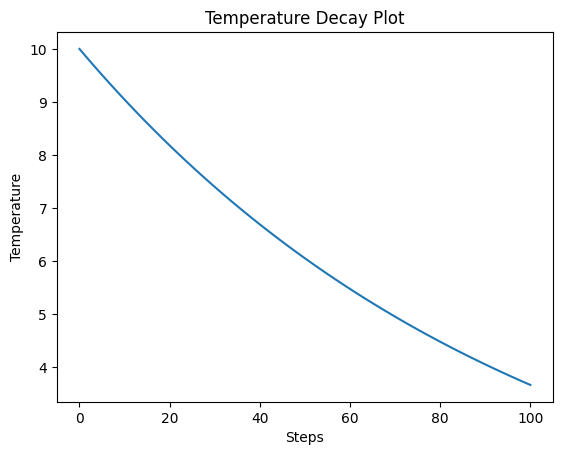

In [25]:
plt.plot(temperatures)
plt.xlabel("Steps")
plt.ylabel("Temperature")
plt.title("Temperature Decay Plot")
plt.show()

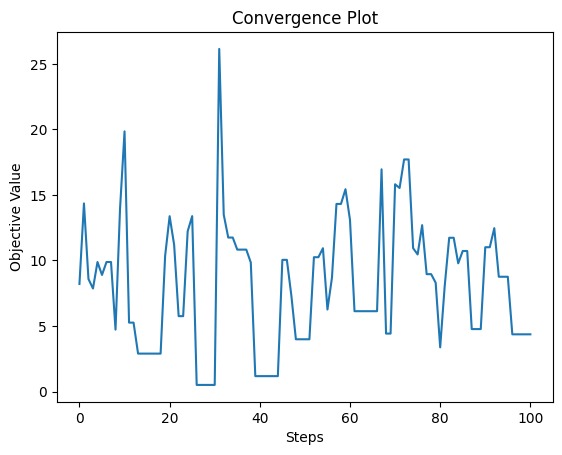

In [26]:
plt.plot(costs)
plt.xlabel("Steps")
plt.ylabel("Objective Value")
plt.title("Convergence Plot")
plt.show()

In [27]:
print("Best parameters found:", best_params)

Best parameters found: ['RNN', 43, 3, True, 0.0067987679542225584]


In [28]:
lstm_config = SingleStepRNNConfig(
    rnn_type="RNN",
    input_size=12,  # 7 for multivariate time series
    hidden_size=43,
    num_layers=3,
    bidirectional=True,
    learning_rate=0.006798,
)
model = SingleStepRNNModel(lstm_config)
model.float()

trainer = pl.Trainer(
    min_epochs=5,
    max_epochs=100,
    callbacks=[pl.callbacks.EarlyStopping(monitor="valid_loss", patience=3)],
)
trainer.fit(model, datamodule)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name | Type    | Params
---------------------------------
0 | rnn  | RNN     | 27.4 K
1 | fc   | Linear  | 87    
2 | loss | MSELoss | 0     
---------------------------------
27.5 K    Trainable params
0         Non-trainable params
27.5 K    Total params
0.110     Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\olarinoyem\AppData\Local\miniconda3\envs\pyt_env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:441: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
c:\Users\olarinoyem\AppData\Local\miniconda3\envs\pyt_env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
c:\Users\olarinoyem\AppData\Local\miniconda3\envs\pyt_env\lib\site-packages\pytorch_lightning\loops\fit_loop.py:293: The number of training batches (13) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [29]:
predictions = trainer.predict(model, datamodule.test_dataloader())
predictions = torch.cat(predictions).squeeze().detach().numpy()

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\olarinoyem\AppData\Local\miniconda3\envs\pyt_env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:441: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

In [30]:
# De-normalizing the predictions
predictions = predictions * datamodule.train.std + datamodule.train.mean

actuals = test["covidOccupiedMVBeds"].values

assert (
    actuals.shape == predictions.shape
), "Mismatch in shapes between actuals and predictions"

In [31]:
algorithm_name = lstm_config.rnn_type

metrics = {
    "Algorithm": algorithm_name,
    "MAE": mae(actuals, predictions),
    "MSE": mse(actuals, predictions),
    "MASE": mase(actuals, predictions, train["covidOccupiedMVBeds"].values),
    "Forecast Bias": forecast_bias(actuals, predictions),
}

value_formats = ["{}", "{:.4f}", "{:.4f}", "{:.4f}", "{:.2f}"]
metrics = {
    key: format_.format(value)
    for key, value, format_ in zip(metrics.keys(), metrics.values(), value_formats)
}

metric_record.append(metrics)
print(metrics)

{'Algorithm': 'RNN', 'MAE': '9.7105', 'MSE': '103.3514', 'MASE': '26.3430', 'Forecast Bias': '-9.71'}


In [33]:
pred_df_ = pd.DataFrame({"LSTM": predictions}, index=test.index)
pred_df = test.join(pred_df_)

# Plotting the forecast
fig = plot_forecast(pred_df, forecast_columns=["LSTM"], forecast_display_names=["LSTM"])
title = f"{lstm_config.rnn_type}: MAE: {metrics['MAE']} | MSE: {metrics['MSE']} | MASE: {metrics['MASE']} | Bias: {metrics['Forecast Bias']}"
fig = format_plot(fig, title=title)
fig.update_xaxes(type="date", range=["2022-10-01", "2022-12-01"])
fig.show()

In [34]:
metric_df = pd.DataFrame(metric_record)
metric_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Algorithm      2 non-null      object
 1   MAE            2 non-null      object
 2   MSE            2 non-null      object
 3   MASE           2 non-null      object
 4   Forecast Bias  2 non-null      object
dtypes: object(5)
memory usage: 208.0+ bytes


In [35]:
metric_df[["MAE", "MSE", "MASE", "Forecast Bias"]] = metric_df[
    ["MAE", "MSE", "MASE", "Forecast Bias"]
].astype("float32")

In [36]:
formatted = metric_df.style.format(
    {
        "MAE": "{:.4f}",
        "MSE": "{:.4f}",
        "MASE": "{:.4f}",
        "Forecast Bias": "{:.2f}%",
        "Time Elapsed": "{:.6f}",
    }
)
formatted = formatted.highlight_min(
    color="lightgreen", subset=["MAE", "MSE", "MASE"]
).apply(
    highlight_abs_min,
    props="color:black;background-color:lightgreen",
    axis=0,
    subset=["Forecast Bias"],
)
formatted

,Algorithm,MAE,MSE,MASE,Forecast Bias
0,LSTM,12.7302,162.8821,34.5349,-12.73%
1,RNN,9.7105,103.3514,26.3430,-9.71%
